<a href="https://colab.research.google.com/github/Baasmaala/road-safety-explorer/blob/osama/03_timeseries_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03 — Time Series & Forecasting
**Road Safety Explorer | IHME Dataset 1990–2019**

**Goals:**
- Track how road traffic deaths changed over time per country (focus: Palestine)
- Fit ARIMA and Holt-Winters models to 30-year trends
- Forecast 2020–2022
- Detect anomaly years where deaths deviated sharply from the trend

**Data:** `output.csv` — 8,010 rows, columns: `Entity, Code, Year, Deaths, Sidedness, Historical_Population`

---
## 0. Setup & Imports

In [2]:
# ── Standard libraries ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ── Statistical / ML ────────────────────────────────────────────────────────
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
PALETTE = {
    'historical': '#2563EB',   # blue
    'arima':      '#16A34A',   # green
    'hw':         '#EA580C',   # orange
    'anomaly':    '#DC2626',   # red
    'ci':         '#BFDBFE',   # light blue
}

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH = 'https://github.com/Baasmaala/road-safety-explorer/raw/osama/data/raw/output.csv'   # adjust if running locally

print('✅ Setup complete')

✅ Setup complete


---
## 1. Data Loading & Preprocessing

In [3]:
# ── Country name normalisation map (shared with Notebook 01) ─────────────────
COUNTRY_NAME_MAP = {
    'occupied Palestinian territory, including east Jerusalem': 'Palestine',
    'Palestinian Territory': 'Palestine',
    'State of Palestine': 'Palestine',
}


def load_ihme_data(path: str | Path) -> pd.DataFrame:
    """
    Load and clean the IHME road-traffic-deaths CSV.

    Returns
    -------
    pd.DataFrame
        Columns: Entity, Code, Year, Deaths, Historical_Population,
                 DeathRate  (deaths per 100 000 people)
    """
    df = pd.read_csv(path)

    # Normalise country names
    df['Entity'] = df['Entity'].replace(COUNTRY_NAME_MAP)

    # Drop rows with missing core values
    df = df.dropna(subset=['Deaths', 'Historical_Population', 'Year'])

    # Compute death rate per 100 000
    df['DeathRate'] = (df['Deaths'] / df['Historical_Population']) * 100_000

    # Sort for time-series work
    df = df.sort_values(['Entity', 'Year']).reset_index(drop=True)

    return df


def get_country_series(df: pd.DataFrame, country: str,
                       metric: str = 'DeathRate') -> pd.Series:
    """
    Extract a time-indexed Series for one country.

    Parameters
    ----------
    df      : full IHME dataframe (output of load_ihme_data)
    country : entity name, e.g. 'Palestine'
    metric  : 'Deaths' | 'DeathRate'

    Returns
    -------
    pd.Series with Year as index
    """
    subset = df[df['Entity'] == country][['Year', metric]].copy()
    subset = subset.set_index('Year').sort_index()
    return subset[metric]


def get_data_quality(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a summary table: countries, year range, row count, any gaps.
    """
    summary = []
    for entity, grp in df.groupby('Entity'):
        years = sorted(grp['Year'].unique())
        expected = set(range(min(years), max(years) + 1))
        gaps = sorted(expected - set(years))
        summary.append({
            'Country': entity,
            'Code': grp['Code'].iloc[0],
            'Years': f"{min(years)}–{max(years)}",
            'Rows': len(grp),
            'Gaps': gaps if gaps else 'None',
        })
    return pd.DataFrame(summary)


# ── Run ───────────────────────────────────────────────────────────────────────
df = load_ihme_data(DATA_PATH)
print(f'Loaded {len(df):,} rows · {df["Entity"].nunique()} countries')
print(f'Year range: {df["Year"].min()}–{df["Year"].max()}')
display(df.head())
display(df[df['Entity'] == 'Palestine'].head(10))

Loaded 6,300 rows · 210 countries
Year range: 1990–2019


,Entity,Code,Year,Deaths,Sidedness,Historical_Population,DeathRate
0,Afghanistan,AFG,1990,4154,0,12412311.0,33.466773
1,Afghanistan,AFG,1991,4472,0,13299016.0,33.626548
2,Afghanistan,AFG,1992,5106,0,14485543.0,35.248938
3,Afghanistan,AFG,1993,5681,0,15816601.0,35.917957
4,Afghanistan,AFG,1994,6001,0,17075728.0,35.143450


,Entity,Code,Year,Deaths,Sidedness,Historical_Population,DeathRate
4290,Palestine,PSE,1990,315,0,2101445.0,14.989686
4291,Palestine,PSE,1991,316,0,2191000.0,14.422638
4292,Palestine,PSE,1992,315,0,2287676.0,13.769432
4293,Palestine,PSE,1993,314,0,2391399.0,13.130389
4294,Palestine,PSE,1994,312,0,2501973.0,12.470159
4295,Palestine,PSE,1995,312,0,2618671.0,11.914441
4296,Palestine,PSE,1996,314,0,2742534.0,11.449266
4297,Palestine,PSE,1997,315,0,2872006.0,10.967944
4298,Palestine,PSE,1998,313,0,3000624.0,10.431164
4299,Palestine,PSE,1999,309,0,3119868.0,9.904265


---
## 2. Exploratory Time Series Analysis

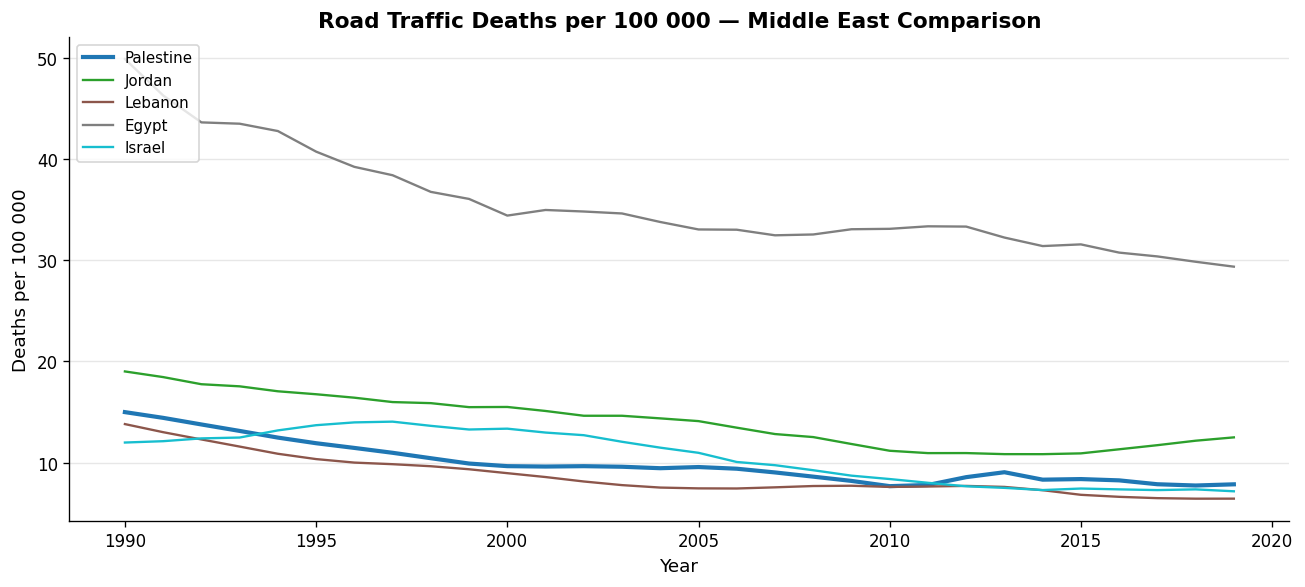

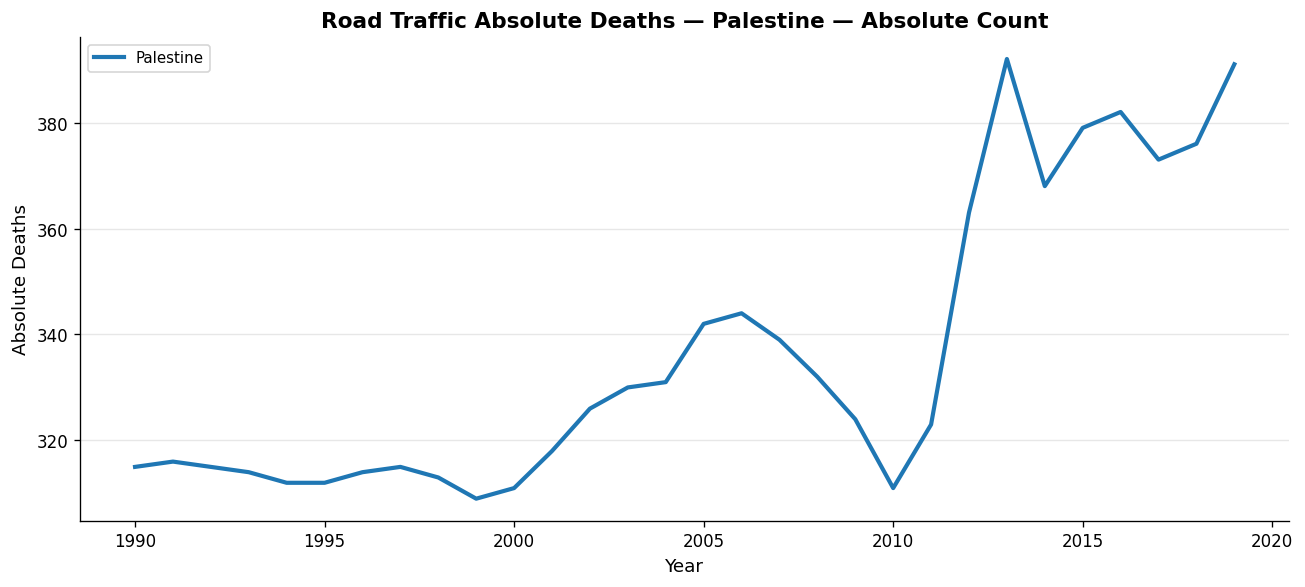


ADF Test — Palestine Death Rate
  ADF Statistic: -2.7572
  p-value: 0.0647
  Verdict: Non-stationary ⚠️

Year-over-Year Change — Palestine


,YoY_Change_%
Year,
2005,1.23%
2006,-1.73%
2007,-3.92%
2008,-4.61%
2009,-4.90%
2010,-6.33%
2011,1.51%
2012,9.95%
2013,5.70%


In [4]:
def plot_country_trend(df: pd.DataFrame, countries: list[str],
                       metric: str = 'DeathRate',
                       title_suffix: str = '') -> plt.Figure:
    """
    Plot the time trend of `metric` for a list of countries.

    Parameters
    ----------
    df       : full IHME dataframe
    countries: list of country names to overlay
    metric   : 'Deaths' | 'DeathRate'

    Returns
    -------
    matplotlib Figure
    """
    fig, ax = plt.subplots(figsize=(11, 5))
    cmap = plt.cm.get_cmap('tab10', len(countries))

    for i, country in enumerate(countries):
        s = get_country_series(df, country, metric)
        lw = 2.5 if country == 'Palestine' else 1.4
        ax.plot(s.index, s.values, label=country, linewidth=lw, color=cmap(i))

    label = 'Deaths per 100 000' if metric == 'DeathRate' else 'Absolute Deaths'
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'Road Traffic {label} — {title_suffix}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    return fig


def run_adf_test(series: pd.Series) -> dict:
    """
    Augmented Dickey-Fuller stationarity test.

    Returns a dict with statistic, p-value, and verdict.
    """
    result = adfuller(series.dropna(), autolag='AIC')
    verdict = 'Stationary ✅' if result[1] < 0.05 else 'Non-stationary ⚠️'
    return {
        'ADF Statistic': round(result[0], 4),
        'p-value':       round(result[1], 4),
        'Verdict':       verdict,
    }


def compute_percent_change(df: pd.DataFrame, country: str,
                           metric: str = 'DeathRate') -> pd.DataFrame:
    """
    Year-over-year % change for a country's metric.
    """
    s = get_country_series(df, country, metric)
    pct = s.pct_change() * 100
    return pd.DataFrame({'Year': pct.index, 'YoY_Change_%': pct.values})


# ── Run EDA ───────────────────────────────────────────────────────────────────
COMPARISON_COUNTRIES = ['Palestine', 'Jordan', 'Lebanon', 'Egypt', 'Israel']

fig1 = plot_country_trend(df, COMPARISON_COUNTRIES, 'DeathRate',
                           title_suffix='Middle East Comparison')
plt.show()

fig2 = plot_country_trend(df, ['Palestine'], 'Deaths',
                           title_suffix='Palestine — Absolute Count')
plt.show()

# ADF test
pse_series = get_country_series(df, 'Palestine', 'DeathRate')
adf_result = run_adf_test(pse_series)
print('\nADF Test — Palestine Death Rate')
for k, v in adf_result.items():
    print(f'  {k}: {v}')

# YoY change
yoy = compute_percent_change(df, 'Palestine', 'DeathRate')
print('\nYear-over-Year Change — Palestine')
display(yoy.set_index('Year').tail(15).style.format({'YoY_Change_%': '{:.2f}%'}))

---
## 3. Forecasting — ARIMA & Holt-Winters

In [5]:
# ── Train / Test split ────────────────────────────────────────────────────────
TRAIN_END = 2016    # train on 1990–2016
TEST_END  = 2019    # test  on 2017–2019
FORECAST_YEARS = [2020, 2021, 2022]   # 3-year forward forecast


def split_series(series: pd.Series,
                 train_end: int = TRAIN_END) -> tuple[pd.Series, pd.Series]:
    """
    Split a time series into train and test subsets.

    Returns
    -------
    (train, test) as pd.Series
    """
    train = series[series.index <= train_end]
    test  = series[series.index >  train_end]
    return train, test


def evaluate_forecast(actual: pd.Series, predicted: pd.Series) -> dict:
    """
    Compute MAE and RMSE between actual and predicted values.

    Parameters
    ----------
    actual    : pd.Series of actual values (test set)
    predicted : pd.Series of model predictions (same index)

    Returns
    -------
    dict with MAE, RMSE, MAPE
    """
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'MAPE_%': round(mape, 2)}


# ─────────────────────────────────────────────────────────────────────────────
# Model 1: ARIMA
# ─────────────────────────────────────────────────────────────────────────────
def fit_arima(train: pd.Series, order: tuple = (1, 1, 1)) -> object:
    """
    Fit an ARIMA model on the training series.

    Parameters
    ----------
    train : training time series
    order : (p, d, q) — default (1,1,1) is a sensible starting point
            for a 30-year annual series with a trend

    Returns
    -------
    Fitted ARIMAResultsWrapper
    """
    model = ARIMA(train, order=order)
    return model.fit()


def forecast_arima(fitted_model, train: pd.Series,
                   n_test: int = 3, n_future: int = 3) -> dict:
    """
    Generate test-period and future forecasts from a fitted ARIMA model.

    Returns
    -------
    dict with keys:
        test_pred  : pd.Series — predictions for test years
        future_pred: pd.Series — predictions for FORECAST_YEARS
        conf_int   : pd.DataFrame — 95% confidence interval for future
    """
    total_steps = n_test + n_future
    forecast    = fitted_model.get_forecast(steps=total_steps)
    pred_mean   = forecast.predicted_mean
    conf_int    = forecast.conf_int(alpha=0.05)

    last_year   = train.index[-1]
    future_years = list(range(last_year + 1, last_year + total_steps + 1))

    pred_series = pd.Series(pred_mean.values, index=future_years)
    ci_df = pd.DataFrame({
        'lower': conf_int.iloc[:, 0].values,
        'upper': conf_int.iloc[:, 1].values,
    }, index=future_years)

    return {
        'test_pred':   pred_series.iloc[:n_test],
        'future_pred': pred_series.iloc[n_test:],
        'conf_int':    ci_df.iloc[n_test:],
    }


# ─────────────────────────────────────────────────────────────────────────────
# Model 2: Holt-Winters
# ─────────────────────────────────────────────────────────────────────────────
def fit_holt_winters(train: pd.Series,
                     trend: str = 'add',
                     damped: bool = True) -> object:
    """
    Fit a Holt-Winters exponential smoothing model (no seasonal component
    — annual data has no sub-annual seasonality).

    Parameters
    ----------
    train   : training time series
    trend   : 'add' (additive) or 'mul' (multiplicative)
    damped  : whether to dampen the trend (helps avoid over-extrapolation)

    Returns
    -------
    Fitted HoltWintersResultsWrapper
    """
    model = ExponentialSmoothing(
        train,
        trend=trend,
        damped_trend=damped,
        seasonal=None,   # annual data — no seasonality
        initialization_method='estimated',
    )
    return model.fit(optimized=True)


def forecast_holt_winters(fitted_model, train: pd.Series,
                           n_test: int = 3, n_future: int = 3) -> dict:
    """
    Generate test-period and future forecasts from a fitted Holt-Winters model.

    Returns
    -------
    dict with keys:
        test_pred  : pd.Series — predictions for test years
        future_pred: pd.Series — predictions for FORECAST_YEARS
        conf_int   : pd.DataFrame — approximate 95% CI (±1.96 × residual std)
    """
    total_steps = n_test + n_future
    pred_values = fitted_model.forecast(total_steps)

    last_year    = train.index[-1]
    future_years = list(range(last_year + 1, last_year + total_steps + 1))

    pred_series = pd.Series(pred_values.values, index=future_years)

    # Approximate CI: ±1.96 × std of in-sample residuals
    resid_std = np.std(fitted_model.resid)
    ci_df = pd.DataFrame({
        'lower': pred_series.iloc[n_test:].values - 1.96 * resid_std,
        'upper': pred_series.iloc[n_test:].values + 1.96 * resid_std,
    }, index=future_years[n_test:])

    return {
        'test_pred':   pred_series.iloc[:n_test],
        'future_pred': pred_series.iloc[n_test:],
        'conf_int':    ci_df,
    }


print('✅ Forecasting functions defined')

✅ Forecasting functions defined


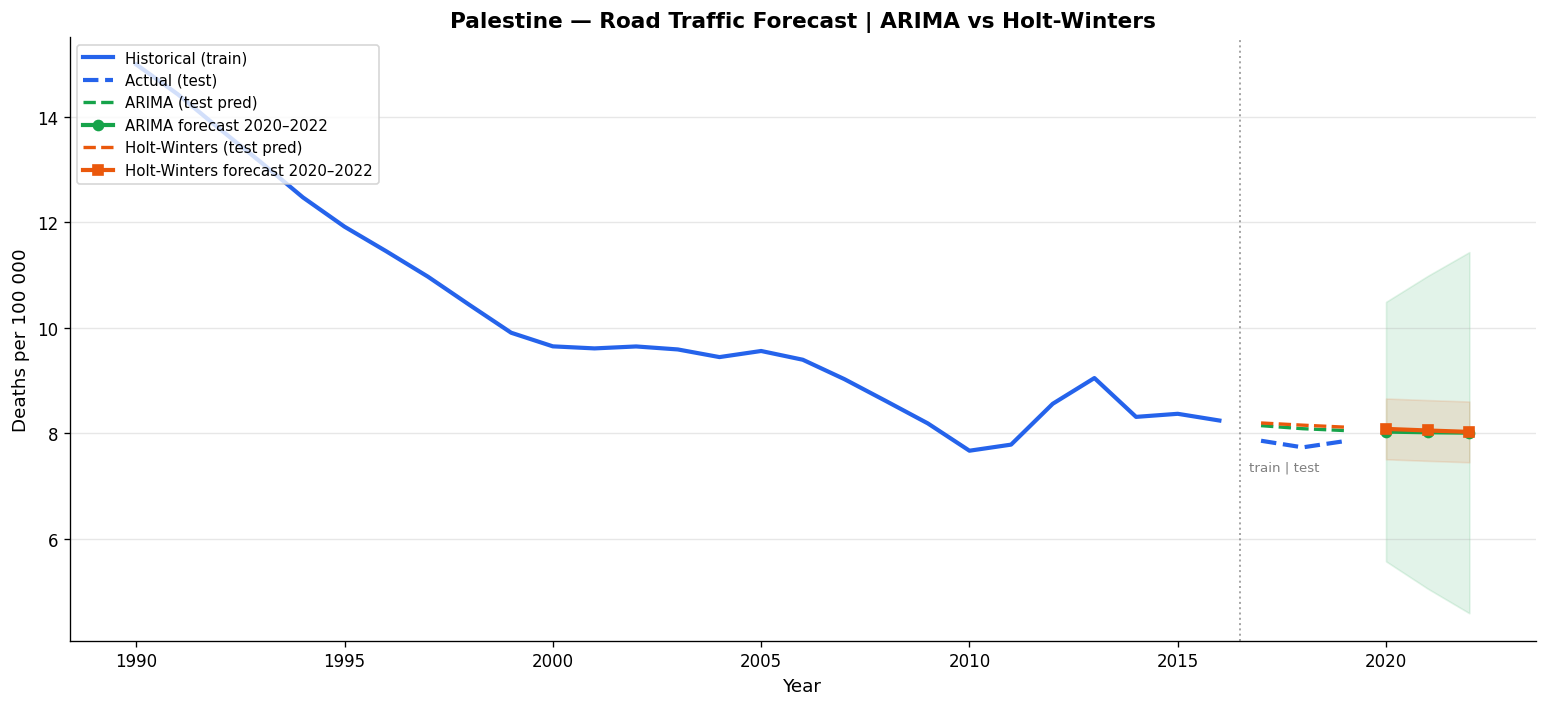


📊 Model Accuracy on Test Set (2017–2019) — Palestine DeathRate


,MAE,RMSE,MAPE_%
Model,,,
ARIMA,0.2805,0.2874,3.60
Holt-Winters,0.3414,0.3472,4.38


In [6]:
def run_full_forecast(df: pd.DataFrame, country: str,
                      metric: str = 'DeathRate') -> dict:
    """
    Full forecasting pipeline for one country:
      1. Extract series  2. Split  3. Fit ARIMA + HW  4. Evaluate  5. Return results

    Parameters
    ----------
    df      : full IHME dataframe
    country : entity name
    metric  : 'Deaths' | 'DeathRate'

    Returns
    -------
    dict with keys: series, train, test, arima, hw, scores
    """
    series = get_country_series(df, country, metric)
    train, test = split_series(series)
    n_test = len(test)

    # ── ARIMA ─────────────────────────────────────────────────────────────────
    arima_model = fit_arima(train)
    arima_out   = forecast_arima(arima_model, train, n_test=n_test)
    arima_scores = evaluate_forecast(test, arima_out['test_pred'])

    # ── Holt-Winters ──────────────────────────────────────────────────────────
    hw_model = fit_holt_winters(train)
    hw_out   = forecast_holt_winters(hw_model, train, n_test=n_test)
    hw_scores = evaluate_forecast(test, hw_out['test_pred'])

    return {
        'country': country,
        'metric':  metric,
        'series':  series,
        'train':   train,
        'test':    test,
        'arima':   {'model': arima_model, **arima_out, 'scores': arima_scores},
        'hw':      {'model': hw_model,    **hw_out,    'scores': hw_scores},
    }


def plot_forecast(results: dict, show_ci: bool = True) -> plt.Figure:
    """
    Plot historical data + both model fits + test predictions + future forecasts.

    Parameters
    ----------
    results  : output of run_full_forecast()
    show_ci  : whether to shade confidence intervals

    Returns
    -------
    matplotlib Figure
    """
    country = results['country']
    series  = results['series']
    train   = results['train']
    test    = results['test']

    arima_test   = results['arima']['test_pred']
    arima_future = results['arima']['future_pred']
    arima_ci     = results['arima']['conf_int']

    hw_test      = results['hw']['test_pred']
    hw_future    = results['hw']['future_pred']
    hw_ci        = results['hw']['conf_int']

    fig, ax = plt.subplots(figsize=(13, 6))

    # Historical
    ax.plot(train.index, train.values, color=PALETTE['historical'],
            linewidth=2.5, label='Historical (train)', zorder=3)
    ax.plot(test.index, test.values, color=PALETTE['historical'],
            linewidth=2.5, linestyle='--', label='Actual (test)', zorder=3)

    # Train/test divider
    ax.axvline(x=TRAIN_END + 0.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(TRAIN_END + 0.7, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0,
            'train | test', fontsize=8, color='gray')

    # ARIMA
    ax.plot(arima_test.index, arima_test.values, color=PALETTE['arima'],
            linewidth=2, linestyle='--', label='ARIMA (test pred)')
    ax.plot(arima_future.index, arima_future.values, color=PALETTE['arima'],
            linewidth=2.5, marker='o', label='ARIMA forecast 2020–2022')
    if show_ci:
        ax.fill_between(arima_ci.index, arima_ci['lower'], arima_ci['upper'],
                        color=PALETTE['arima'], alpha=0.12)

    # Holt-Winters
    ax.plot(hw_test.index, hw_test.values, color=PALETTE['hw'],
            linewidth=2, linestyle='--', label='Holt-Winters (test pred)')
    ax.plot(hw_future.index, hw_future.values, color=PALETTE['hw'],
            linewidth=2.5, marker='s', label='Holt-Winters forecast 2020–2022')
    if show_ci:
        ax.fill_between(hw_ci.index, hw_ci['lower'], hw_ci['upper'],
                        color=PALETTE['hw'], alpha=0.12)

    label = 'Deaths per 100 000' if results['metric'] == 'DeathRate' else 'Absolute Deaths'
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{country} — Road Traffic Forecast | ARIMA vs Holt-Winters',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    return fig


# ── Run for Palestine ─────────────────────────────────────────────────────────
pse_results = run_full_forecast(df, 'Palestine', metric='DeathRate')

fig = plot_forecast(pse_results)
plt.show()

# Scores comparison table
scores_df = pd.DataFrame([
    {'Model': 'ARIMA',        **pse_results['arima']['scores']},
    {'Model': 'Holt-Winters', **pse_results['hw']['scores']},
]).set_index('Model')

print('\n📊 Model Accuracy on Test Set (2017–2019) — Palestine DeathRate')
display(scores_df)

---
## 4. Temporal Anomaly Detection

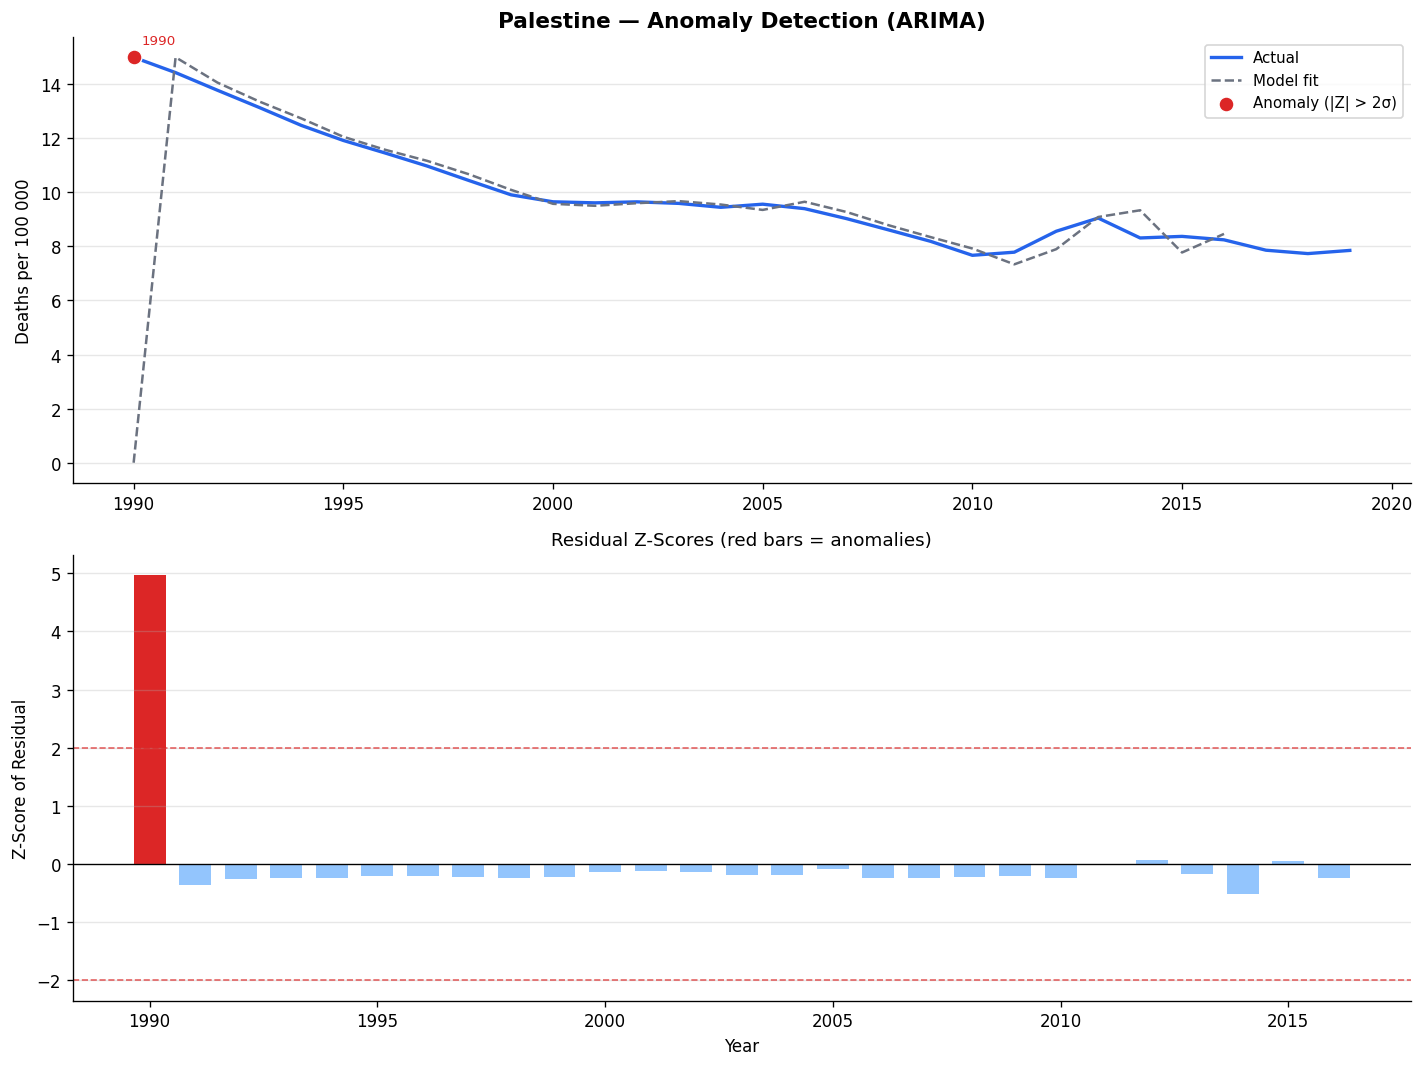


🚨 Anomaly Years — Palestine


,Year,Actual,Fitted,Residual,Z_Score
0,1990,14.99,0.00,14.99,4.97


In [7]:
def detect_anomalies(series: pd.Series, fitted_model,
                     model_type: str = 'arima',
                     threshold_std: float = 2.0) -> pd.DataFrame:
    """
    Flag years where actual deaths deviate sharply from the model's expectation.

    Strategy: use the in-sample (training) residuals to compute a baseline
    noise level.  Years where |residual| > threshold_std × σ are flagged.

    Parameters
    ----------
    series        : full time series (train + test)
    fitted_model  : fitted ARIMA or HW model
    model_type    : 'arima' | 'hw'  — determines how to get fitted values
    threshold_std : number of standard deviations for the anomaly threshold

    Returns
    -------
    pd.DataFrame with columns: Year, Actual, Fitted, Residual, Z_Score, Anomaly
    """
    if model_type == 'arima':
        fitted_values = fitted_model.fittedvalues
    else:  # holt-winters
        fitted_values = fitted_model.fittedvalues

    # Align to common index (training period)
    common_idx = series.index.intersection(fitted_values.index)
    actual  = series.loc[common_idx]
    fitted  = fitted_values.loc[common_idx]
    resid   = actual - fitted

    mu    = resid.mean()
    sigma = resid.std()
    z     = (resid - mu) / sigma

    result = pd.DataFrame({
        'Year':     common_idx,
        'Actual':   actual.values,
        'Fitted':   fitted.values,
        'Residual': resid.values,
        'Z_Score':  z.values,
        'Anomaly':  (z.abs() > threshold_std).values,
    })
    return result


def plot_anomalies(series: pd.Series, anomaly_df: pd.DataFrame,
                   country: str = '', model_name: str = '') -> plt.Figure:
    """
    Plot the time series with anomaly years highlighted.

    Parameters
    ----------
    series     : full country time series
    anomaly_df : output of detect_anomalies()
    country    : label for the title
    model_name : 'ARIMA' | 'Holt-Winters'

    Returns
    -------
    matplotlib Figure
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))

    # ── Top: time series with anomaly markers ──────────────────────────────
    ax = axes[0]
    ax.plot(series.index, series.values, color=PALETTE['historical'],
            linewidth=2, label='Actual', zorder=2)
    ax.plot(anomaly_df['Year'], anomaly_df['Fitted'],
            color='#6B7280', linewidth=1.5, linestyle='--', label='Model fit', zorder=2)

    anom = anomaly_df[anomaly_df['Anomaly']]
    ax.scatter(anom['Year'], anom['Actual'],
               color=PALETTE['anomaly'], s=80, zorder=5,
               label=f'Anomaly (|Z| > 2σ)', edgecolors='white', linewidths=0.8)

    for _, row in anom.iterrows():
        ax.annotate(str(int(row['Year'])),
                    xy=(row['Year'], row['Actual']),
                    xytext=(5, 8), textcoords='offset points',
                    fontsize=8, color=PALETTE['anomaly'])

    ax.set_title(f'{country} — Anomaly Detection ({model_name})',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Deaths per 100 000', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # ── Bottom: residual / Z-score bar chart ───────────────────────────────
    ax2 = axes[1]
    colors = [PALETTE['anomaly'] if a else '#93C5FD'
              for a in anomaly_df['Anomaly']]
    ax2.bar(anomaly_df['Year'], anomaly_df['Z_Score'], color=colors, width=0.7)
    ax2.axhline(y= 2, color=PALETTE['anomaly'], linestyle='--', linewidth=1, alpha=0.7)
    ax2.axhline(y=-2, color=PALETTE['anomaly'], linestyle='--', linewidth=1, alpha=0.7)
    ax2.axhline(y= 0, color='black', linewidth=0.8)
    ax2.set_xlabel('Year', fontsize=10)
    ax2.set_ylabel('Z-Score of Residual', fontsize=10)
    ax2.set_title('Residual Z-Scores (red bars = anomalies)', fontsize=11)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    return fig


# ── Run anomaly detection on Palestine ────────────────────────────────────────
arima_fitted = pse_results['arima']['model']
pse_series   = pse_results['series']

anom_df = detect_anomalies(pse_series, arima_fitted, model_type='arima')

fig = plot_anomalies(pse_series, anom_df, country='Palestine', model_name='ARIMA')
plt.show()

print('\n🚨 Anomaly Years — Palestine')
display(anom_df[anom_df['Anomaly']][['Year','Actual','Fitted','Residual','Z_Score']]
        .style.format({'Actual':'{:.2f}','Fitted':'{:.2f}',
                       'Residual':'{:.2f}','Z_Score':'{:.2f}'}))

---
## 5. Regional Analysis

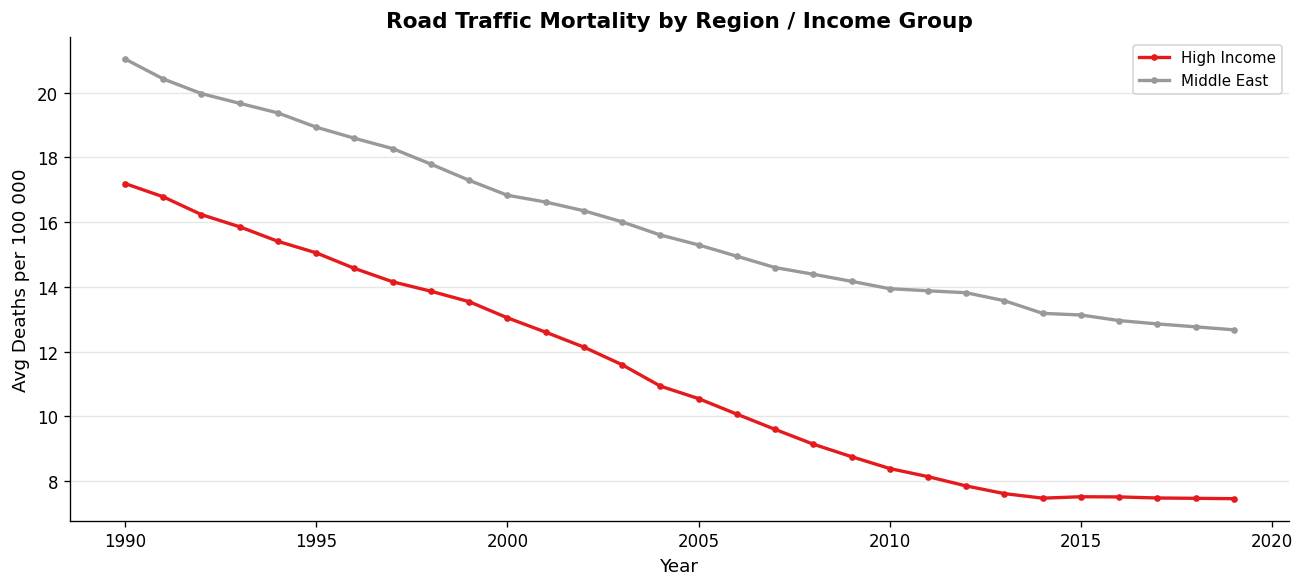

Group,High Income,Middle East
Year,,
2015,7.51,13.13
2016,7.51,12.96
2017,7.48,12.85
2018,7.47,12.76
2019,7.45,12.67


In [8]:
# ── Comparison countries (neighbours + world) ─────────────────────────────────
REGIONAL_GROUPS = {
    'Middle East': ['Palestine', 'Jordan', 'Lebanon', 'Egypt',
                    'Syria', 'Israel', 'Iraq'],
    'High Income':  ['Germany', 'France', 'Japan', 'United States'],
    'Global':       ['Global'],   # if present in dataset
}


def compute_group_trends(df: pd.DataFrame,
                         groups: dict[str, list[str]],
                         metric: str = 'DeathRate') -> pd.DataFrame:
    """
    Compute the average metric by group and year.

    Parameters
    ----------
    df     : full IHME dataframe
    groups : {group_name: [country, ...]}
    metric : 'Deaths' | 'DeathRate'

    Returns
    -------
    pd.DataFrame  wide format: Year × Group
    """
    records = []
    for group_name, countries in groups.items():
        subset = df[df['Entity'].isin(countries)]
        if subset.empty:
            continue
        group_avg = subset.groupby('Year')[metric].mean().reset_index()
        group_avg['Group'] = group_name
        records.append(group_avg)

    result = pd.concat(records, ignore_index=True)
    return result.pivot(index='Year', columns='Group', values=metric)


def plot_group_trends(trends: pd.DataFrame, metric: str = 'DeathRate') -> plt.Figure:
    """
    Line chart of group-level trends.
    """
    fig, ax = plt.subplots(figsize=(11, 5))
    cmap = plt.cm.get_cmap('Set1', len(trends.columns))

    for i, col in enumerate(trends.columns):
        ax.plot(trends.index, trends[col], label=col,
                linewidth=2, color=cmap(i), marker='o', markersize=3)

    label = 'Avg Deaths per 100 000' if metric == 'DeathRate' else 'Avg Absolute Deaths'
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title('Road Traffic Mortality by Region / Income Group', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    return fig


# ── Run ───────────────────────────────────────────────────────────────────────
trends = compute_group_trends(df, REGIONAL_GROUPS)
fig = plot_group_trends(trends)
plt.show()
display(trends.tail(5).style.format('{:.2f}'))

---
## 6. Palestine Deep Dive — Full Report

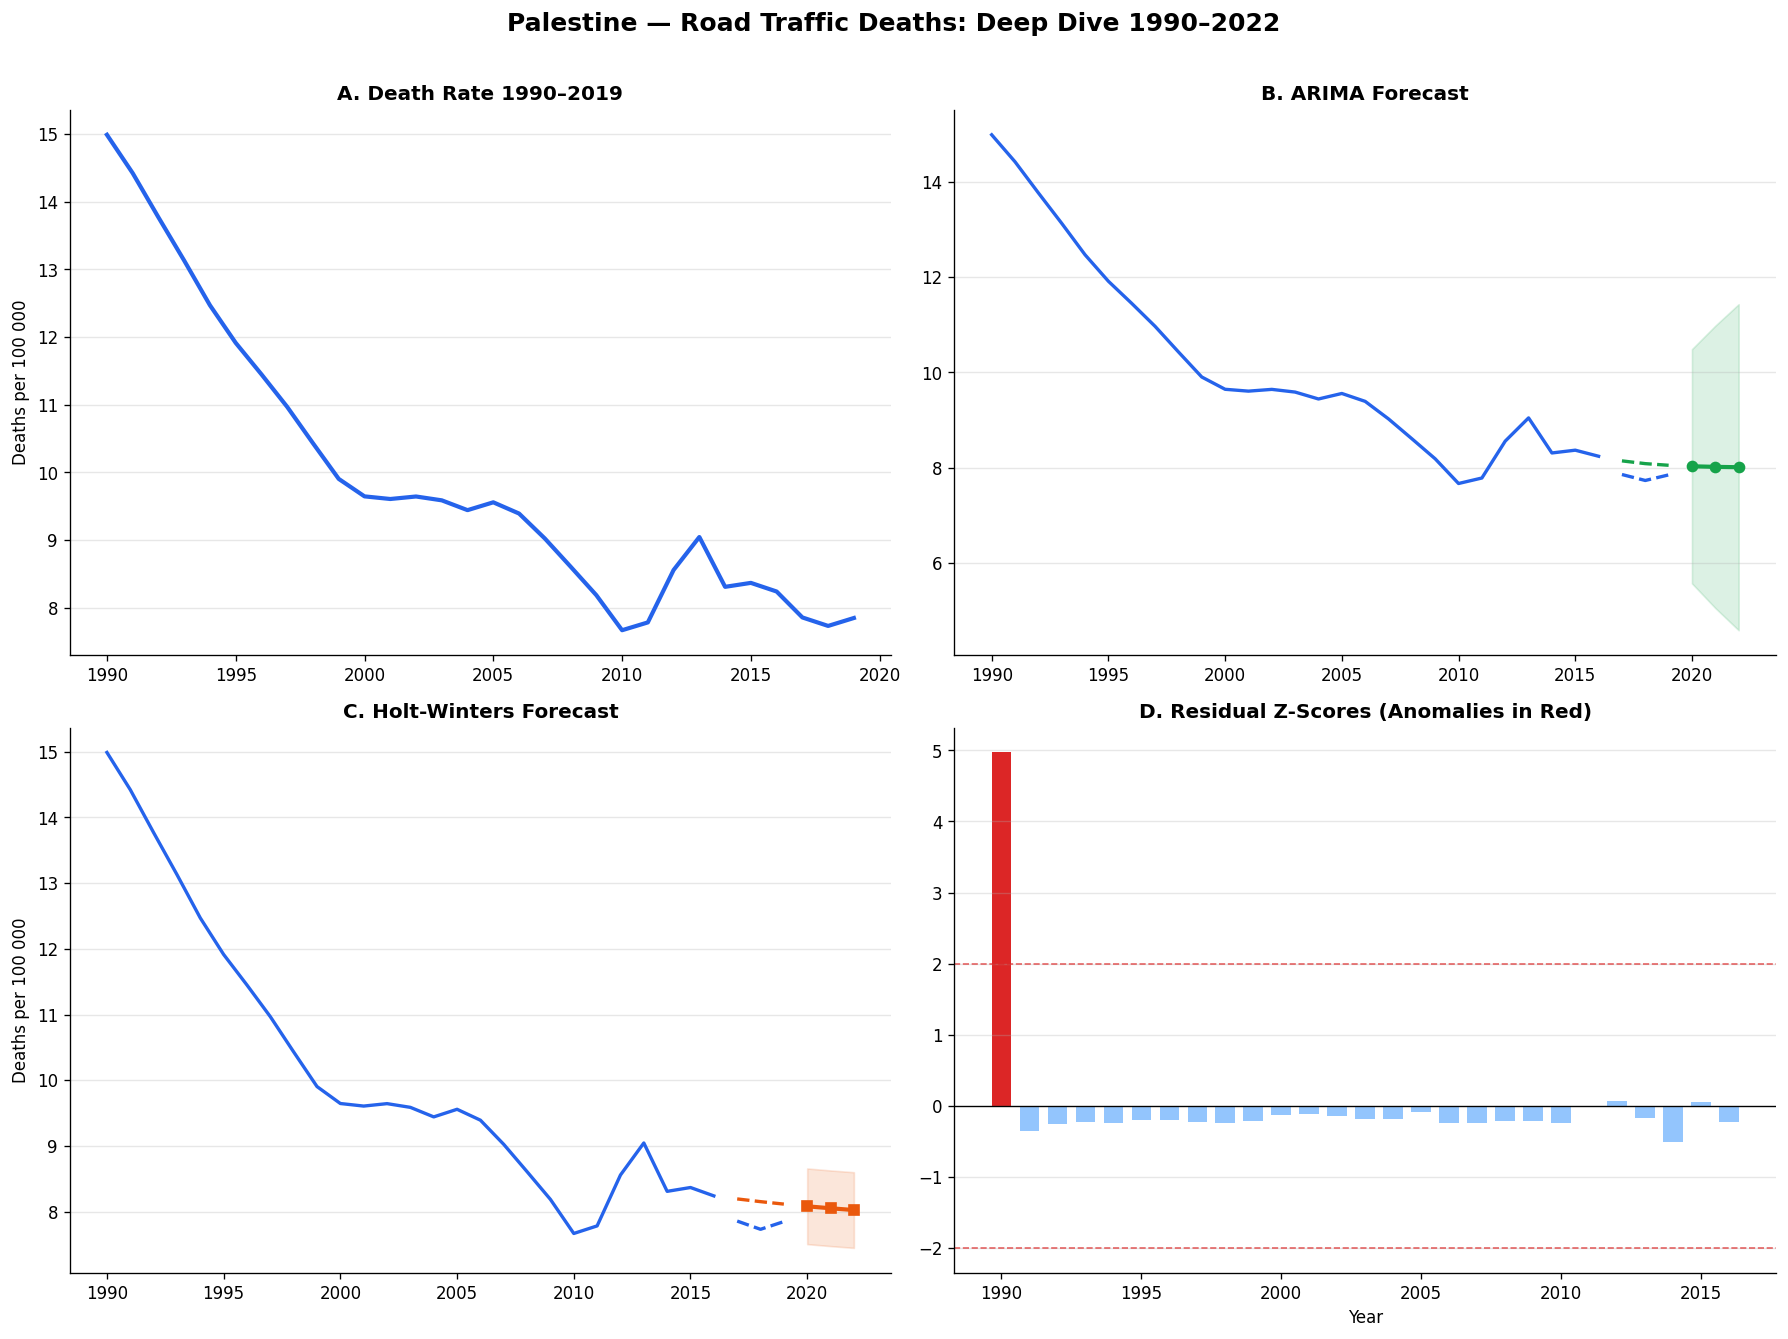


📋 Palestine Summary Statistics
  death_rate_1990: 14.99
  death_rate_2019: 7.849
  peak_year: 1990
  peak_rate: 14.99
  n_anomaly_years: 1
  anomaly_years: [1990]
  arima_forecast_2022: 8.01
  hw_forecast_2022: 8.025

📊 ARIMA Accuracy: {'MAE': 0.2805, 'RMSE': np.float64(0.2874), 'MAPE_%': np.float64(3.6)}
📊 Holt-Winters Accuracy: {'MAE': 0.3414, 'RMSE': np.float64(0.3472), 'MAPE_%': np.float64(4.38)}

🚨 Anomaly Years:


,Year,Actual,Fitted,Residual,Z_Score
0,1990,14.990,0.000,14.990,4.97


In [9]:
def palestine_full_report(df: pd.DataFrame) -> dict:
    """
    Generate a comprehensive 4-panel report for Palestine.

    Returns
    -------
    dict with keys:
        fig          : matplotlib Figure (4 subplots)
        arima_scores : accuracy metrics
        hw_scores    : accuracy metrics
        anomalies    : DataFrame of anomaly years
        summary      : dict of key statistics
    """
    results = run_full_forecast(df, 'Palestine', metric='DeathRate')
    series  = results['series']

    # Anomalies from ARIMA
    anom_df = detect_anomalies(series, results['arima']['model'], model_type='arima')

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle('Palestine — Road Traffic Deaths: Deep Dive 1990–2022',
                 fontsize=15, fontweight='bold', y=1.01)

    # ── Panel A: Raw trend ─────────────────────────────────────────────────
    ax = axes[0, 0]
    ax.plot(series.index, series.values, color=PALETTE['historical'], linewidth=2.5)
    ax.set_title('A. Death Rate 1990–2019', fontweight='bold')
    ax.set_ylabel('Deaths per 100 000')
    ax.grid(axis='y', alpha=0.3)

    # ── Panel B: ARIMA forecast ────────────────────────────────────────────
    ax = axes[0, 1]
    ax.plot(results['train'].index, results['train'].values,
            color=PALETTE['historical'], linewidth=2)
    ax.plot(results['test'].index, results['test'].values,
            color=PALETTE['historical'], linewidth=2, linestyle='--')
    ax.plot(results['arima']['test_pred'].index, results['arima']['test_pred'].values,
            color=PALETTE['arima'], linewidth=2, linestyle='--')
    ax.plot(results['arima']['future_pred'].index, results['arima']['future_pred'].values,
            color=PALETTE['arima'], linewidth=2.5, marker='o')
    ci = results['arima']['conf_int']
    ax.fill_between(ci.index, ci['lower'], ci['upper'], color=PALETTE['arima'], alpha=0.15)
    ax.set_title('B. ARIMA Forecast', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # ── Panel C: HW forecast ───────────────────────────────────────────────
    ax = axes[1, 0]
    ax.plot(results['train'].index, results['train'].values,
            color=PALETTE['historical'], linewidth=2)
    ax.plot(results['test'].index, results['test'].values,
            color=PALETTE['historical'], linewidth=2, linestyle='--')
    ax.plot(results['hw']['test_pred'].index, results['hw']['test_pred'].values,
            color=PALETTE['hw'], linewidth=2, linestyle='--')
    ax.plot(results['hw']['future_pred'].index, results['hw']['future_pred'].values,
            color=PALETTE['hw'], linewidth=2.5, marker='s')
    ci_hw = results['hw']['conf_int']
    ax.fill_between(ci_hw.index, ci_hw['lower'], ci_hw['upper'], color=PALETTE['hw'], alpha=0.15)
    ax.set_title('C. Holt-Winters Forecast', fontweight='bold')
    ax.set_ylabel('Deaths per 100 000')
    ax.grid(axis='y', alpha=0.3)

    # ── Panel D: Z-score anomalies ─────────────────────────────────────────
    ax = axes[1, 1]
    bar_colors = [PALETTE['anomaly'] if a else '#93C5FD' for a in anom_df['Anomaly']]
    ax.bar(anom_df['Year'], anom_df['Z_Score'], color=bar_colors, width=0.7)
    ax.axhline(y= 2, color=PALETTE['anomaly'], linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(y=-2, color=PALETTE['anomaly'], linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(y= 0, color='black', linewidth=0.8)
    ax.set_title('D. Residual Z-Scores (Anomalies in Red)', fontweight='bold')
    ax.set_xlabel('Year')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    summary = {
        'death_rate_1990':    round(series.loc[1990], 3),
        'death_rate_2019':    round(series.loc[2019], 3),
        'peak_year':          int(series.idxmax()),
        'peak_rate':          round(series.max(), 3),
        'n_anomaly_years':    int(anom_df['Anomaly'].sum()),
        'anomaly_years':      list(anom_df[anom_df['Anomaly']]['Year'].astype(int)),
        'arima_forecast_2022': round(results['arima']['future_pred'].iloc[-1], 3),
        'hw_forecast_2022':    round(results['hw']['future_pred'].iloc[-1], 3),
    }

    return {
        'fig':          fig,
        'arima_scores': results['arima']['scores'],
        'hw_scores':    results['hw']['scores'],
        'anomalies':    anom_df[anom_df['Anomaly']],
        'summary':      summary,
    }


# ── Run ───────────────────────────────────────────────────────────────────────
report = palestine_full_report(df)
plt.show()

print('\n📋 Palestine Summary Statistics')
for k, v in report['summary'].items():
    print(f'  {k}: {v}')

print('\n📊 ARIMA Accuracy:', report['arima_scores'])
print('📊 Holt-Winters Accuracy:', report['hw_scores'])

print('\n🚨 Anomaly Years:')
display(report['anomalies'][['Year','Actual','Fitted','Residual','Z_Score']]
        .style.format({'Actual':'{:.3f}','Fitted':'{:.3f}',
                       'Residual':'{:.3f}','Z_Score':'{:.2f}'}))

---
## 7. Streamlit API
> هذه الدالة هي واجهة الـ Streamlit — تُرجع كل البيانات التي يحتاجها الـ page في هيكل واضح.

✅ Streamlit API keys: ['series', 'train', 'test', 'arima_test_pred', 'arima_future', 'arima_ci', 'hw_test_pred', 'hw_future', 'hw_ci', 'anomalies', 'arima_scores', 'hw_scores', 'summary', 'forecast_fig', 'anomaly_fig']
   Summary: {'country': 'Palestine', 'metric': 'DeathRate', 'death_rate_1990': np.float64(14.99), 'death_rate_2019': np.float64(7.849), 'overall_change_%': np.float64(-47.64), 'peak_year': 1990, 'n_anomaly_years': 1, 'anomaly_years': [1990], 'arima_forecast_2020': np.float64(8.03), 'arima_forecast_2022': np.float64(8.01), 'hw_forecast_2020': np.float64(8.082), 'hw_forecast_2022': np.float64(8.025)}


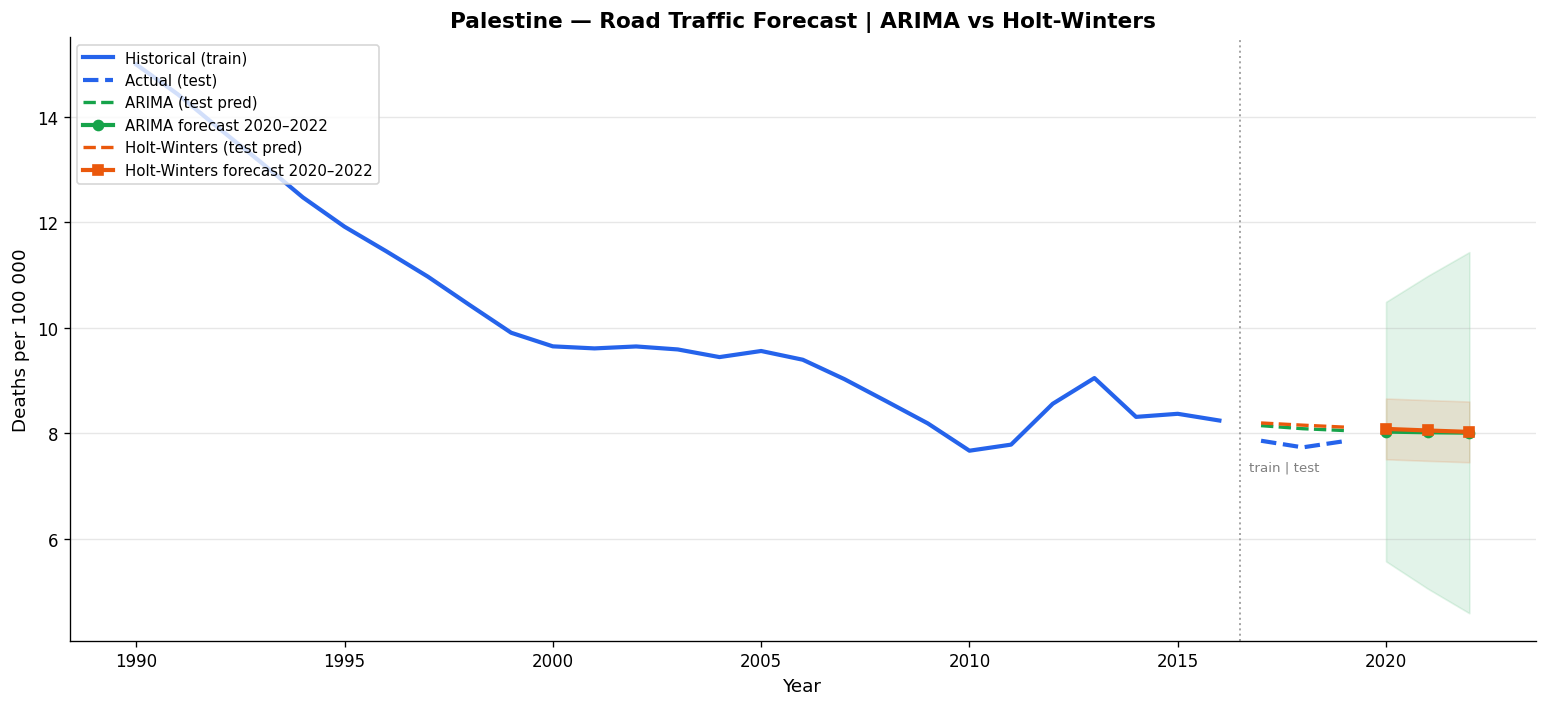

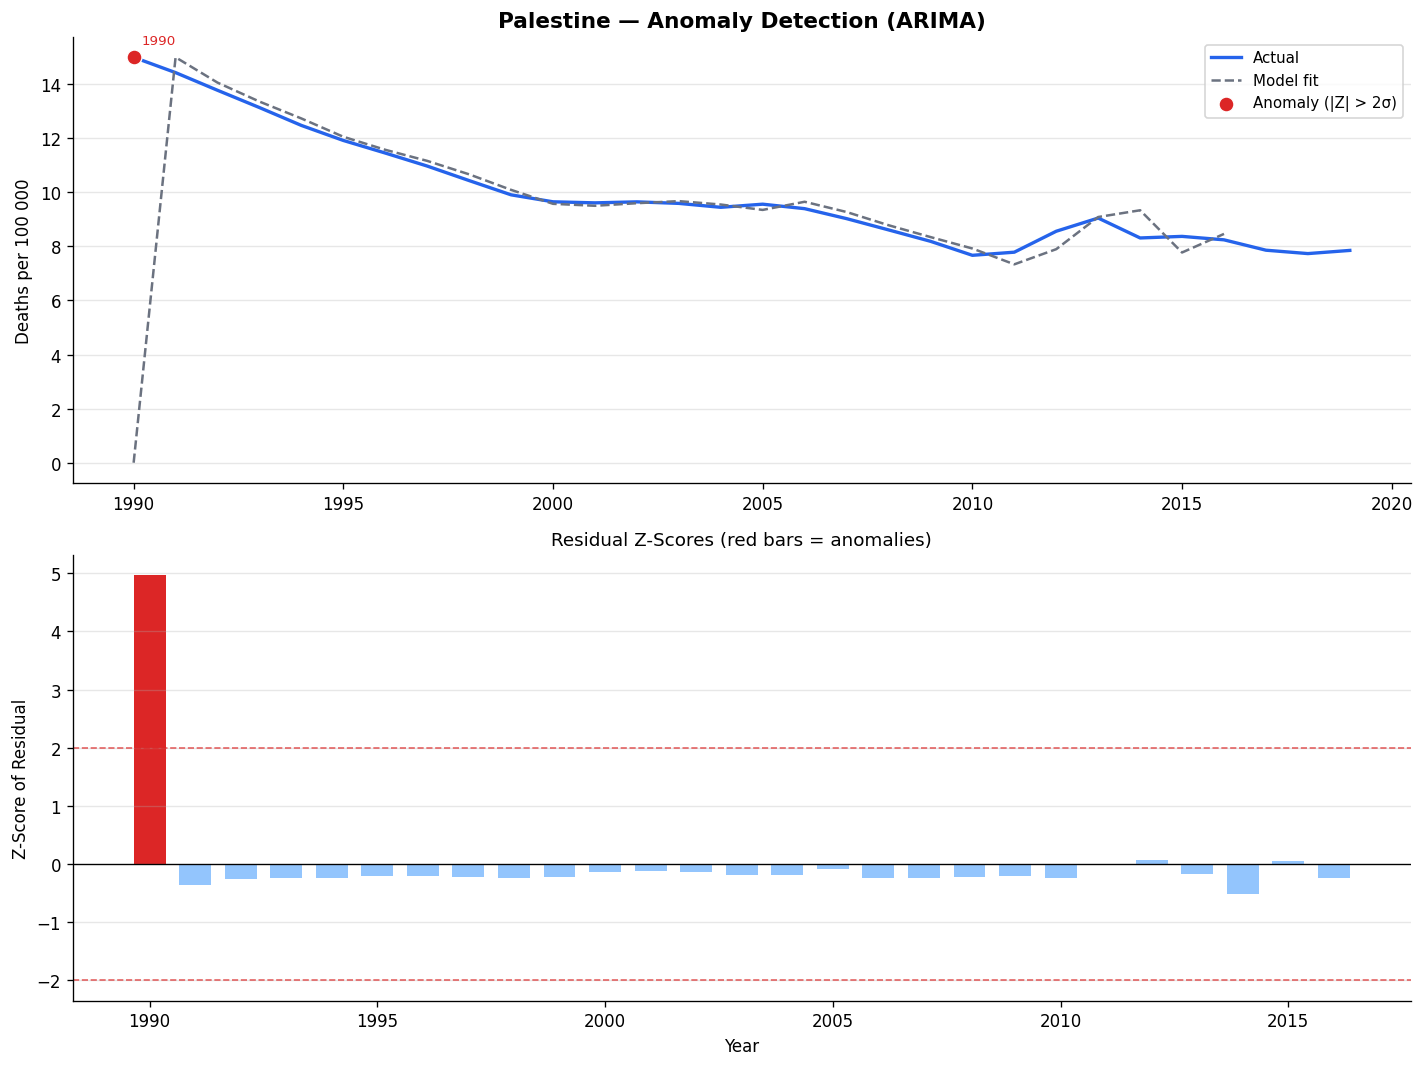

In [10]:
def get_timeseries_page_data(country: str,
                              metric: str = 'DeathRate',
                              data_path: str | Path = DATA_PATH) -> dict:
    """
    Single entry point for the Streamlit time-series page.

    Call this function from the Streamlit page; it returns a structured dict
    with everything the UI needs.

    Parameters
    ----------
    country   : selected country name (e.g. 'Palestine')
    metric    : 'DeathRate' or 'Deaths'
    data_path : path to output.csv

    Returns
    -------
    dict with keys:
        series          pd.Series  — full 1990–2019 series
        train           pd.Series  — training split (≤2016)
        test            pd.Series  — test split (2017–2019)
        arima_test_pred pd.Series  — ARIMA predictions on test
        arima_future    pd.Series  — ARIMA forecast 2020–2022
        arima_ci        pd.DataFrame — CI for arima_future
        hw_test_pred    pd.Series
        hw_future       pd.Series
        hw_ci           pd.DataFrame
        anomalies       pd.DataFrame — anomaly detection table
        arima_scores    dict — MAE, RMSE, MAPE
        hw_scores       dict
        summary         dict — key stats
        forecast_fig    matplotlib Figure — full 4-model forecast plot
        anomaly_fig     matplotlib Figure — anomaly chart
    """
    # Load data
    df      = load_ihme_data(data_path)
    results = run_full_forecast(df, country, metric)
    series  = results['series']

    # Anomaly detection
    anom_df = detect_anomalies(series, results['arima']['model'], model_type='arima')

    # Figures
    forecast_fig = plot_forecast(results)
    anomaly_fig  = plot_anomalies(series, anom_df, country=country, model_name='ARIMA')

    # Summary stats
    summary = {
        'country':              country,
        'metric':               metric,
        'death_rate_1990':      round(series.iloc[0], 3),
        'death_rate_2019':      round(series.iloc[-1], 3),
        'overall_change_%':     round((series.iloc[-1] / series.iloc[0] - 1) * 100, 2),
        'peak_year':            int(series.idxmax()),
        'n_anomaly_years':      int(anom_df['Anomaly'].sum()),
        'anomaly_years':        list(anom_df[anom_df['Anomaly']]['Year'].astype(int)),
        'arima_forecast_2020':  round(results['arima']['future_pred'].iloc[0], 3),
        'arima_forecast_2022':  round(results['arima']['future_pred'].iloc[-1], 3),
        'hw_forecast_2020':     round(results['hw']['future_pred'].iloc[0], 3),
        'hw_forecast_2022':     round(results['hw']['future_pred'].iloc[-1], 3),
    }

    return {
        'series':           series,
        'train':            results['train'],
        'test':             results['test'],
        'arima_test_pred':  results['arima']['test_pred'],
        'arima_future':     results['arima']['future_pred'],
        'arima_ci':         results['arima']['conf_int'],
        'hw_test_pred':     results['hw']['test_pred'],
        'hw_future':        results['hw']['future_pred'],
        'hw_ci':            results['hw']['conf_int'],
        'anomalies':        anom_df,
        'arima_scores':     results['arima']['scores'],
        'hw_scores':        results['hw']['scores'],
        'summary':          summary,
        'forecast_fig':     forecast_fig,
        'anomaly_fig':      anomaly_fig,
    }


# ── Quick smoke test ──────────────────────────────────────────────────────────
page_data = get_timeseries_page_data('Palestine')
print('✅ Streamlit API keys:', list(page_data.keys()))
print('   Summary:', page_data['summary'])

---
## 8. Limitations & Notes

| Limitation | Detail |
|---|---|
| **Data ends in 2019** | Forecasts for 2020–2022 do **not** capture COVID-19's effect on road usage and fatalities |
| **IHME modelled estimates** | The death counts are IHME model outputs, not direct counts — they carry their own uncertainty |
| **ARIMA order fixed** | We use (1,1,1) as a reasonable default; auto-ARIMA could further optimise p,d,q |
| **No seasonality** | Annual data means no monthly seasonality is modelled — this is intentional |
| **Conflict years** | Anomalies around 2012–2014 likely reflect the 2014 Gaza conflict's indirect effects on mobility and reporting |
| **Forecasts are projections** | They assume past trends continue and do not account for policy changes, conflict, or infrastructure investment |